In [38]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Feature selection
from sklearn.feature_selection import chi2, mutual_info_classif, SelectKBest
from scipy.stats import f_oneway

# Classification algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# Pour affichage
from IPython.display import display
import time


In [6]:
dataset = pd.read_csv("E-commerce_Dataset.csv", names = ['category' , 'description'],header = None)

In [7]:
dataset.head()

,category,description
0,Household,Paper Plane Design Framed Wall Hanging Motivat...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
4,Household,Incredible Gifts India Wooden Happy Birthday U...


In [8]:
len(dataset)

50425

In [19]:
dataset.isnull().sum()
dataset.dropna()


dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 50425 entries, 0 to 50424
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   category     50425 non-null  str  
 1   description  50424 non-null  str  
dtypes: str(2)
memory usage: 788.0 KB


In [27]:
df_clean = dataset[['category' , 'description']].dropna()

df_clean.isnull().sum()



category       0
description    0
dtype: int64

In [ ]:
label_encoder = LabelEncoder()
df_clean['category_encoded'] = label_encoder.fit_transform(df_clean['category'])


X= df_clean['description']
y = df_clean['category_encoded']

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size= 0.2 , random_state= 42 , stratify= y) 

In [51]:
tfidf_vectorizer = TfidfVectorizer(
    max_features= 5000,
    min_df= 2,
    max_df=0.8,
    ngram_range=(1,2),
    stop_words='english'
)


X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Forme de la matrice TF-IDF d'entainement {X_train_tfidf.shape}")

Forme de la matrice TF-IDF d'entainement (40339, 5000)


In [54]:
k_features = 1000

chi2_selector = SelectKBest(chi2 , k = k_features)
X_train_chi2 = chi2_selector.fit_transform(X_train_tfidf , y_train)
X_test_chi2 = chi2_selector.transform(X_test_tfidf)

print(X_train_chi2.shape)
print(X_test_chi2.shape)

print(len(tfidf_vectorizer.get_feature_names_out()))

(40339, 1000)
(10085, 1000)
5000


In [56]:
mi_selector = SelectKBest(mutual_info_classif , k= k_features)
X_train_mi = mi_selector.fit_transform(X_train_tfidf , y_train)
X_test_mi = mi_selector.transform(X_test_tfidf)

print(X_train_mi.shape)
print(X_train_mi.shape[1])

(40339, 1000)


In [58]:
from sklearn.feature_selection import f_classif

fisher_selector = SelectKBest(f_classif , k= k_features)
X_train_fisher = fisher_selector.fit_transform(X_train_tfidf , y_train)
X_test_fisher = fisher_selector.transform(X_test_tfidf)

In [59]:
classifiers = {
    'Decision Tree' : DecisionTreeClassifier(random_state=42 , max_depth=10), 
    'KNN' : KNeighborsClassifier(n_neighbors= 5),
    'SVM' : SVC(kernel = 'linear' , random_state=42),
    'XGBoost' : XGBClassifier(random_state= 42 , eval_metric = 'mlogloss' , use_label_encoder = False)
}

In [61]:
results = []

feature_selection_methods = {
    'No Selection ' : (X_train_tfidf , X_test_tfidf),
    'Chi-Square' : (X_train_chi2 , X_test_chi2),
    'Mutual information' : (X_train_mi , X_test_mi) ,
    'Information Gain' : (X_train_mi , X_test_mi) ,
    'Fisher Score' : (X_train_fisher , X_test_fisher)
}

In [62]:
# Entraîner et évaluer chaque combinaison
for fs_method, (X_tr, X_te) in feature_selection_methods.items():
    print(f"\n{'='*70}")
    print(f"Méthode de sélection: {fs_method}")
    print(f"{'='*70}")
    
    for clf_name, classifier in classifiers.items():
        print(f"\n  Classifieur: {clf_name}")
        
        # Entraînement
        start_time = time.time()
        classifier.fit(X_tr, y_train)
        training_time = time.time() - start_time
        
        # Prédiction
        start_time = time.time()
        y_pred = classifier.predict(X_te)
        prediction_time = time.time() - start_time
        
        # Calcul des métriques
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        # Stocker les résultats
        results.append({
            'Feature Selection': fs_method,
            'Classifier': clf_name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'Training Time (s)': training_time,
            'Prediction Time (s)': prediction_time
        })
        
        print(f"    Accuracy: {accuracy:.4f}")
        print(f"    Precision: {precision:.4f}")
        print(f"    Recall: {recall:.4f}")
        print(f"    F1-Score: {f1:.4f}")
        print(f"    Training Time: {training_time:.3f}s")

print("\n" + "="*70)
print("Entraînement et évaluation terminés!")


Méthode de sélection: No Selection 

  Classifieur: Decision Tree
    Accuracy: 0.7664
    Precision: 0.8367
    Recall: 0.7664
    F1-Score: 0.7618
    Training Time: 2.618s

  Classifieur: KNN
    Accuracy: 0.7418
    Precision: 0.8666
    Recall: 0.7418
    F1-Score: 0.7600
    Training Time: 0.012s

  Classifieur: SVM
    Accuracy: 0.9668
    Precision: 0.9669
    Recall: 0.9668
    F1-Score: 0.9668
    Training Time: 129.903s

  Classifieur: XGBoost
    Accuracy: 0.9567
    Precision: 0.9569
    Recall: 0.9567
    F1-Score: 0.9567
    Training Time: 221.819s

Méthode de sélection: Chi-Square

  Classifieur: Decision Tree
    Accuracy: 0.7628
    Precision: 0.8320
    Recall: 0.7628
    F1-Score: 0.7577
    Training Time: 1.172s

  Classifieur: KNN
    Accuracy: 0.9101
    Precision: 0.9125
    Recall: 0.9101
    F1-Score: 0.9100
    Training Time: 0.007s

  Classifieur: SVM
    Accuracy: 0.9314
    Precision: 0.9334
    Recall: 0.9314
    F1-Score: 0.9313
    Training Time: 67.63

In [63]:
results_df = pd.DataFrame(results)

print("Results in form of a table")

display(results_df.round(4))

Results in form of a table


,Feature Selection,Classifier,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,No Selection,Decision Tree,0.7664,0.8367,0.7664,0.7618,2.6178,0.0043
1,No Selection,KNN,0.7418,0.8666,0.7418,0.7600,0.0117,24.2423
2,No Selection,SVM,0.9668,0.9669,0.9668,0.9668,129.9029,29.2333
3,No Selection,XGBoost,0.9567,0.9569,0.9567,0.9567,221.8193,0.1553
4,Chi-Square,Decision Tree,0.7628,0.8320,0.7628,0.7577,1.1718,0.0024
5,Chi-Square,KNN,0.9101,0.9125,0.9101,0.9100,0.0073,17.5505
6,Chi-Square,SVM,0.9314,0.9334,0.9314,0.9313,67.6332,9.6363
7,Chi-Square,XGBoost,0.9500,0.9504,0.9500,0.9500,49.3995,0.0385
8,Mutual information,Decision Tree,0.7638,0.8328,0.7638,0.7594,1.3135,0.0017
9,Mutual information,KNN,0.8679,0.8790,0.8679,0.8695,0.0053,10.4229


In [64]:
print("=" * 70)
print("Meilleurs resultats par metrique")
print("=" * 70)

metrics = ['Accuracy' , 'Precision' , 'Recall' ,'F1-Score']

for metric in metrics :
    best_row = results_df.loc[results_df[metric].idxmax()]
    print(f"\n{metric}")
    print(f" Methode: {best_row['Feature Selection']}")
    print(f" Classifieur: {best_row['Classifier']}")
    print(f" Score: {best_row[metric]:.4f}")

Meilleurs resultats par metrique

Accuracy
 Methode: No Selection 
 Classifieur: SVM
 Score: 0.9668

Precision
 Methode: No Selection 
 Classifieur: SVM
 Score: 0.9669

Recall
 Methode: No Selection 
 Classifieur: SVM
 Score: 0.9668

F1-Score
 Methode: No Selection 
 Classifieur: SVM
 Score: 0.9668


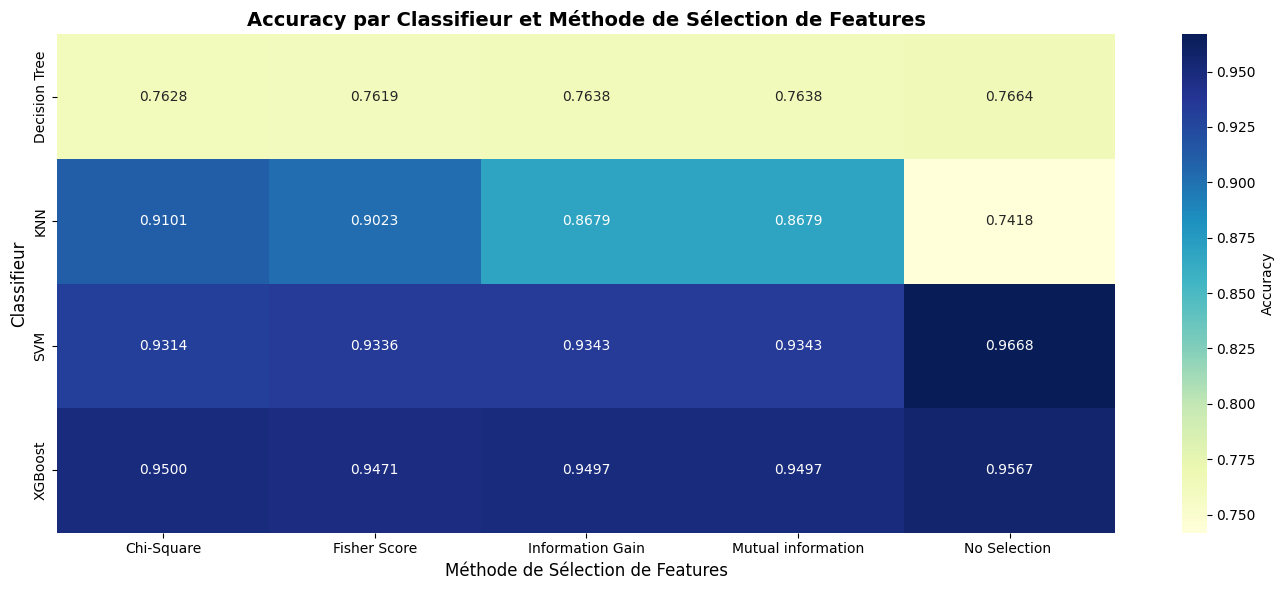

In [65]:
# Heatmap de l'accuracy pour chaque combinaison
pivot_accuracy = results_df.pivot(index='Classifier', columns='Feature Selection', values='Accuracy')

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_accuracy, annot=True, fmt='.4f', cmap='YlGnBu', cbar_kws={'label': 'Accuracy'})
plt.title('Accuracy par Classifieur et Méthode de Sélection de Features', fontsize=14, fontweight='bold')
plt.xlabel('Méthode de Sélection de Features', fontsize=12)
plt.ylabel('Classifieur', fontsize=12)
plt.tight_layout()
plt.show()

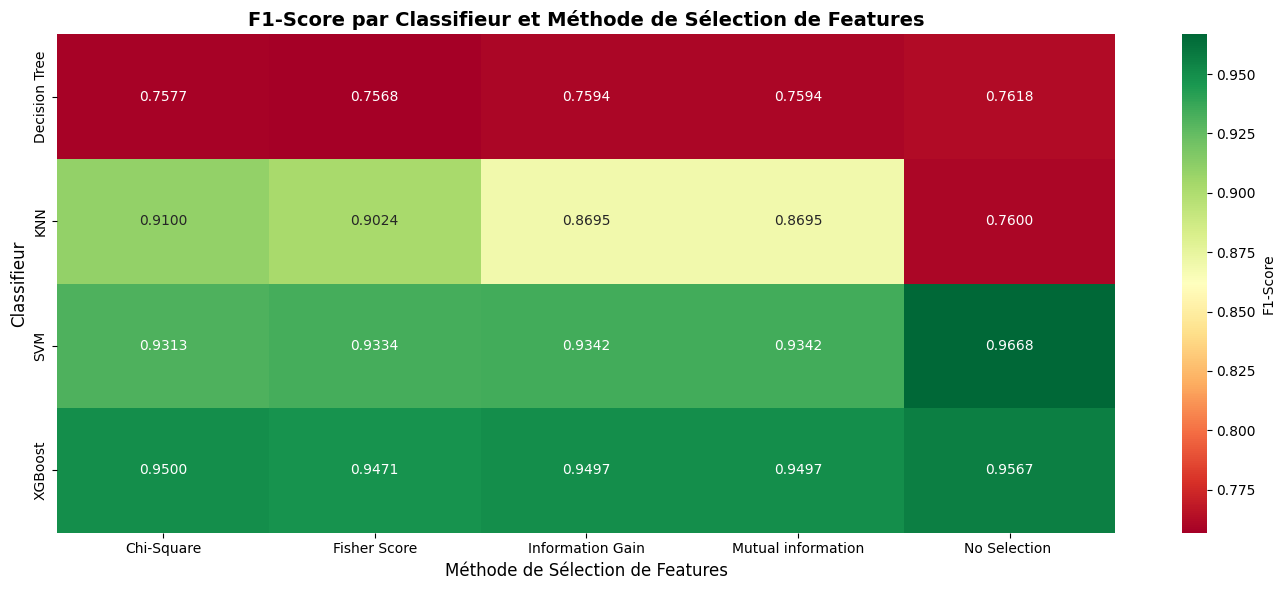

In [ ]:
# Heatmap du F1-Score
pivot_f1 = results_df.pivot(index='Classifier', columns='Feature Selection', values='F1-Score')

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_f1, annot=True, fmt='.4f', cmap='RdYlGn', cbar_kws={'label': 'F1-Score'})
plt.title('F1-Score par Classifieur et Méthode de Sélection de Features', fontsize=14, fontweight='bold')
plt.xlabel('Méthode de Sélection de Features', fontsize=12)
plt.ylabel('Classifieur', fontsize=12)
plt.tight_layout()
plt.show()

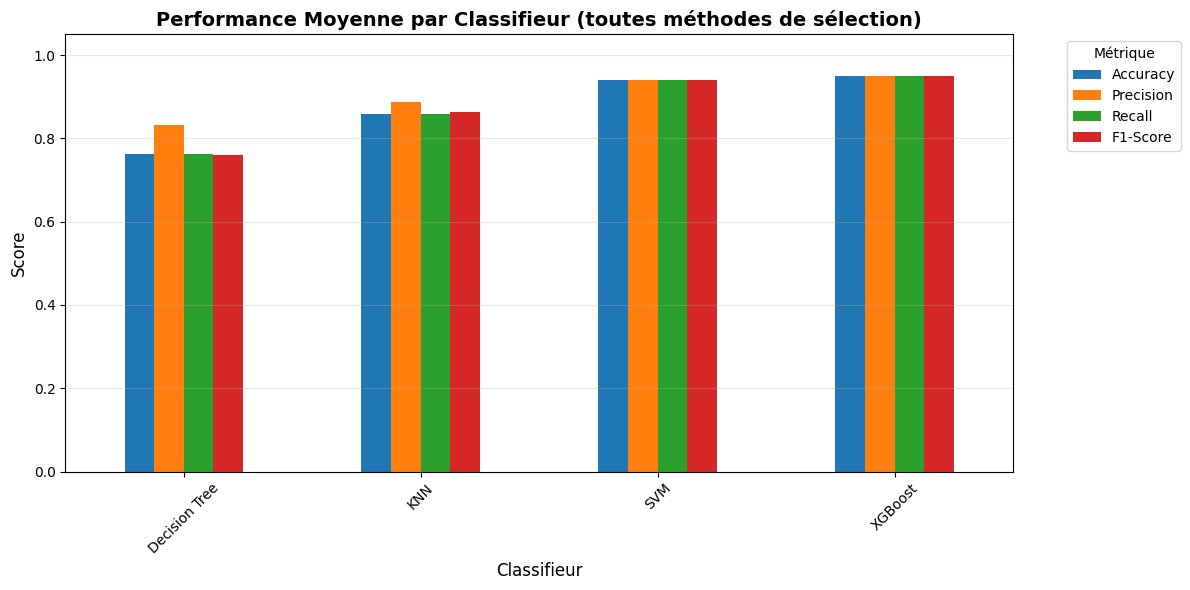


Performance moyenne par classifieur:


,Accuracy,Precision,Recall,F1-Score
Classifier,,,,
Decision Tree,0.7637,0.8327,0.7637,0.7590
KNN,0.8580,0.8885,0.8580,0.8623
SVM,0.9400,0.9409,0.9400,0.9400
XGBoost,0.9507,0.9510,0.9507,0.9507


In [67]:
# Performance moyenne par classifieur (toutes méthodes confondues)
avg_by_classifier = results_df.groupby('Classifier')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].mean()

avg_by_classifier.plot(kind='bar', figsize=(12, 6), rot=45)
plt.title('Performance Moyenne par Classifieur (toutes méthodes de sélection)', fontsize=14, fontweight='bold')
plt.xlabel('Classifieur', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(title='Métrique', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim([0, 1.05])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPerformance moyenne par classifieur:")
display(avg_by_classifier.round(4))

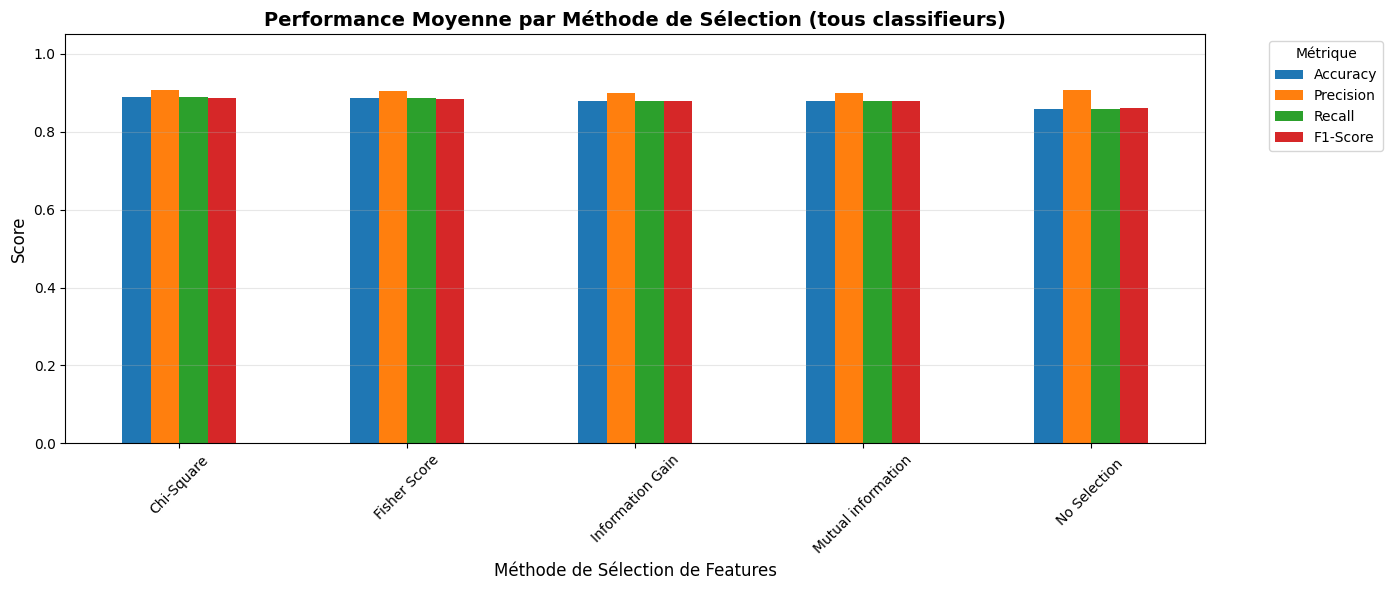


Performance moyenne par méthode de sélection:


,Accuracy,Precision,Recall,F1-Score
Feature Selection,,,,
Chi-Square,0.8886,0.9071,0.8886,0.8872
Fisher Score,0.8862,0.9041,0.8862,0.8850
Information Gain,0.8789,0.8992,0.8789,0.8782
Mutual information,0.8789,0.8992,0.8789,0.8782
No Selection,0.8579,0.9068,0.8579,0.8613


In [68]:
# Performance moyenne par méthode de sélection (tous classifieurs confondus)
avg_by_fs = results_df.groupby('Feature Selection')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].mean()

avg_by_fs.plot(kind='bar', figsize=(14, 6), rot=45)
plt.title('Performance Moyenne par Méthode de Sélection (tous classifieurs)', fontsize=14, fontweight='bold')
plt.xlabel('Méthode de Sélection de Features', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(title='Métrique', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim([0, 1.05])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPerformance moyenne par méthode de sélection:")
display(avg_by_fs.round(4))